# Project: Predicting Clinical Trial Success through Multimodal Data Fusion

This notebook serves as the technical proof of concept for our project. The primary goal is to explore the "louisbrulenaudet/clinical-trials" dataset, establish baseline models for predicting trial success, and demonstrate the feasibility of our proposed multimodal approach.

This notebook is organized as follows:
1.  **Exploratory Data Analysis (EDA):** Understanding the properties and challenges of the dataset.
2.  **Data Splitting and Preprocessing:** Creating a robust pipeline to prepare our data for modeling while preventing data leakage.
3.  **Baseline Model (Structured Data):** Training and evaluating a Random Forest classifier on the structured metadata.
4.  **Embeddings Model (Initial Version):** Training and evaluating models on the generated text embeddings to test the predictive power of the text data.
5.  **Conclusion and Next Steps:** Summarizing our findings and outlining the plan for the final P3 milestone.

In [1]:
# Libraries

# Core Data Handling and Plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hugging Face Datasets
from datasets import load_dataset, Dataset, ClassLabel

# Scikit-learn for Modeling and Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.utils import resample

# Utility Functions (from our utils.py file)
from utils import fit_and_preprocess_train, transform_test_data

# Set plot style for the notebook
sns.set_style("whitegrid")
# Prevent pandas from using scientific notation for easier reading
pd.options.display.float_format = '{:.2f}'.format

In [2]:
# --- Load the Full Raw Dataset ---
# We load the 'train' split, which contains all the available data,
# and immediately convert it to a pandas DataFrame for EDA.
# If you are running this on your local machine, it takes a while to load the dataset. 
print("Loading the full dataset from Hugging Face...")
full_df = load_dataset("louisbrulenaudet/clinical-trials", split="train").to_pandas()
print("Dataset loaded.")

# Display initial information about the dataset
print("\nDataset Information:")
full_df.info()

print("\nFirst 5 rows of the raw dataset:")
display(full_df.head())

Loading the full dataset from Hugging Face...
Dataset loaded.

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541897 entries, 0 to 541896
Data columns (total 46 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   nct_id                        541897 non-null  object        
 1   updated_at                    0 non-null       datetime64[us]
 2   brief_title                   541897 non-null  object        
 3   official_title                531911 non-null  object        
 4   acronym                       541897 non-null  object        
 5   study_type                    540977 non-null  object        
 6   overall_status                541897 non-null  object        
 7   study_first_submit_date       541897 non-null  datetime64[ms]
 8   start_date                    0 non-null       datetime64[ms]
 9   primary_completion_date       296575 non-null  datetime64[ms]
 

,nct_id,updated_at,brief_title,official_title,acronym,study_type,overall_status,study_first_submit_date,start_date,primary_completion_date,...,locations,collaborators,arm_groups,outcomes,overall_officials,study_references,misc_info_module,condition_browse_module,intervention_browse_module,mesh_terms
0,NCT01273766,NaT,Deferasirox in Treating Iron Overload Caused B...,Impact of Intervention With Deferasirox on the...,None,INTERVENTIONAL,COMPLETED,2011-01-07,NaT,NaT,...,"[{'city': 'Winston-Salem', 'country': 'United ...","[{'class': 'NIH', 'name': 'National Cancer Ins...",None,"{'other': None, 'primary': [{'description': No...",[{'affiliation': 'Wake Forest University Healt...,None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D004194', 'term': 'Dise...","{'ancestors': [{'id': 'D007502', 'term': 'Iron...","{'conditions': [{'id': 'D002051', 'term': 'Bur..."
1,NCT00787566,NaT,"Phase 2 Study of Efficacy, Tolerability, and S...","A Randomized, Single Administration, Double-bl...",None,INTERVENTIONAL,COMPLETED,2008-11-05,NaT,NaT,...,[{'city': 'The study is managed by Kendle Inte...,None,None,"{'other': None, 'primary': [{'description': No...",None,None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D012817', 'term': 'Sign...","{'ancestors': [{'id': 'D000932', 'term': 'Anti...","{'conditions': [{'id': 'D009325', 'term': 'Nau..."
2,NCT00497666,NaT,Association Between Rosiglitazone Use and Clin...,Retrospective Study Evaluating the Association...,None,OBSERVATIONAL,UNKNOWN,2007-07-06,NaT,NaT,...,"[{'city': 'Zerifin,', 'country': 'Israel', 'fa...",None,None,None,"[{'affiliation': 'Nephrology Division, Assaf H...",None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D014570', 'term': 'Urol...","{'ancestors': None, 'browseBranches': [{'abbre...","{'conditions': [{'id': 'D007674', 'term': 'Kid..."
3,NCT01978366,NaT,Open Label Extension Study of HT-100 in Patien...,An Open Label Extension Study of HT-100 in Pat...,None,INTERVENTIONAL,TERMINATED,2013-10-31,NaT,2016-04-30,...,"[{'city': 'Sacramento', 'country': 'United Sta...",None,None,"{'other': None, 'primary': [{'description': No...","[{'affiliation': 'AkashiTherapeutics', 'name':...",None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D020966', 'term': 'Musc...","{'ancestors': [{'id': 'D000970', 'term': 'Anti...","{'conditions': [{'id': 'D009136', 'term': 'Mus..."
4,NCT01971866,NaT,Camera Based System to Monitor Patient Movemen...,Improving Safety and Accuracy of Proton Therap...,DS02,OBSERVATIONAL,TERMINATED,2013-10-17,NaT,NaT,...,"[{'city': 'Jacksonville', 'country': 'United S...",None,None,"{'other': None, 'primary': [{'description': No...",[{'affiliation': 'University of Florida Proton...,None,"{""versionHolder"": ""2025-06-18""}",None,None,None


--- Original Distribution of Trial Statuses ---
overall_status
COMPLETED                    296549
UNKNOWN                       79051
RECRUITING                    66429
TERMINATED                    31493
NOT_YET_RECRUITING            23878
ACTIVE_NOT_RECRUITING         20916
WITHDRAWN                     15333
ENROLLING_BY_INVITATION        4655
SUSPENDED                      1674
WITHHELD                        920
NO_LONGER_AVAILABLE             490
AVAILABLE                       264
APPROVED_FOR_MARKETING          220
TEMPORARILY_NOT_AVAILABLE        25
Name: count, dtype: int64


C:\Users\esthe\AppData\Local\Temp\ipykernel_23936\3252186510.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette="viridis")


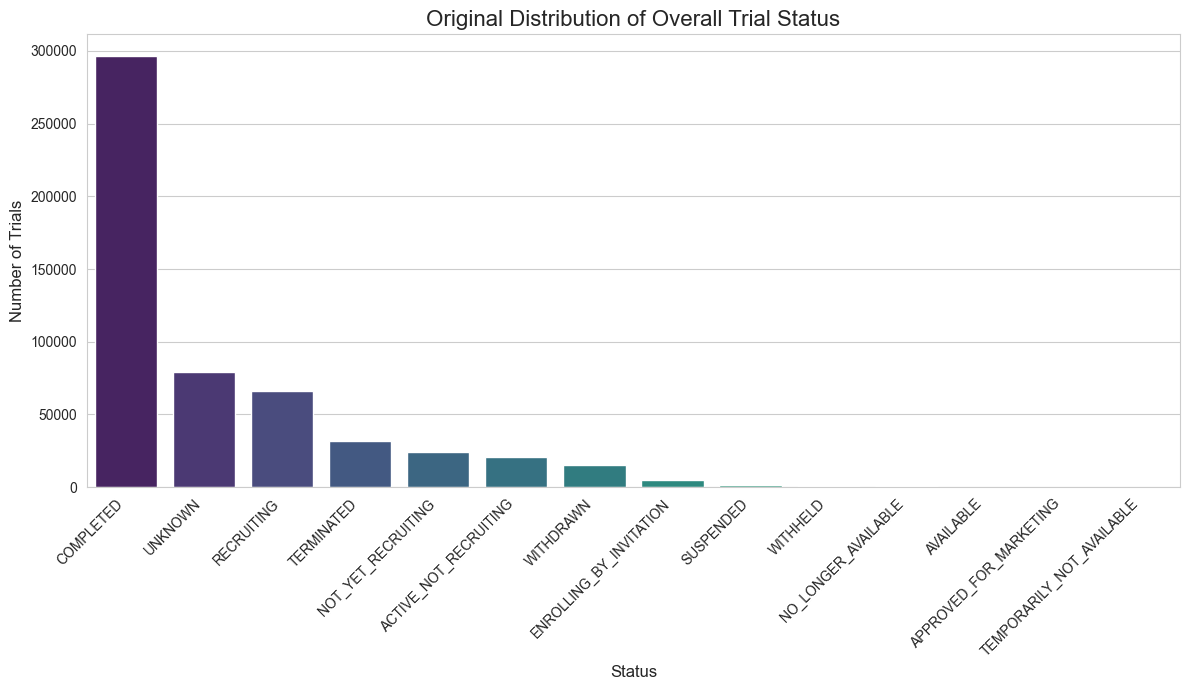

In [ ]:
# --- 1.1. Target Variable Analysis: overall_status ---

# First, we look at the original distribution of the 'overall_status' column.
print("--- Original Distribution of Trial Statuses ---")
status_counts = full_df['overall_status'].value_counts()
print(status_counts)

# Next we visualize the distribution
plt.figure(figsize=(12, 7))
sns.barplot(x=status_counts.index, y=status_counts.values, palette="viridis")
plt.title('Original Distribution of Overall Trial Status', fontsize=16)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Number of Trials', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Defining the Binary Target for EDA

The `overall_status` column contains many different categories, some of which are not definitive outcomes (e.g., "RECRUTING"). For our predictive task, we need a clear binary target representing **Success vs. Failure**. Based on our analysis, we define our classes as follows:

*   **Success (Target = 1):** Trials marked **"COMPLETED"**.
*   **Failure (Target = 0):** Trials that were stopped for definitive negative reasons. We include **"TERMINATED"**, **"WITHDRAWN"**, and **"SUSPENDED"**.

We will filter the dataset to these outcomes to create a clean target for our analysis.

--- Distribution of the Binary Target Variable ---
target
1    296549
0     48500
Name: count, dtype: int64


C:\Users\esthe\AppData\Local\Temp\ipykernel_23936\535026310.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=eda_filtered_df, palette="viridis")


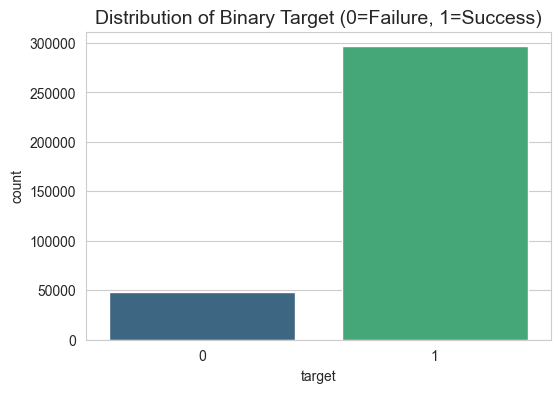

In [5]:
# --- Create a temporary filtered DataFrame for EDA visualization ---
success_stati = ["COMPLETED"]
failure_stati = ["TERMINATED", "WITHDRAWN", "SUSPENDED"]
definitive_stati = success_stati + failure_stati

# Note: This filtered_df is for EDA purposes only. 
# The final filtering for the model will happen within the preprocessing pipeline.
eda_filtered_df = full_df[full_df['overall_status'].isin(definitive_stati)].copy()
eda_filtered_df['target'] = eda_filtered_df['overall_status'].apply(lambda x: 1 if x in success_stati else 0)

# Visualize the new binary target distribution
print("--- Distribution of the Binary Target Variable ---")
print(eda_filtered_df['target'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=eda_filtered_df, palette="viridis")
plt.title('Distribution of Binary Target (0=Failure, 1=Success)', fontsize=14)
plt.show()

# Markdown analysis of the imbalance will go in the final EDA conclusion.

## 1. Exploratory Data Analysis (EDA)

This section is dedicated to developing an "intimate acquaintance" with the clinical trials dataset. Our goals are to understand the structure of the data, identify key patterns and distributions, diagnose potential issues like missing values or class imbalance, and use these findings to inform our data preprocessing and modeling strategy. All analysis in this section is performed on the full, original dataset.


### 1.2. Structured Feature Analysis
First we analyze key structured features that we hypothesize will be predictive of trial success. We selected the following features based on their potential to capture the core design, scope, and operational context of a clinical trial:
*   **`phases`, `study_type`, `enrollment_count`:** These represent the trial's design, scale, and inherent risk.
*   **`lead_sponsor_class`:** Captures the nature of the funding organization (e.g., Industry vs. Academia).
*   **`sex`, `minimum_age`, `maximum_age`:** Define the target patient population and its complexity.

Our analysis will investigate missing values and the distributions of these categorical and numerical features.

In [7]:
# --- Missing Values Analysis ---
structured_features = [
    'phases', 'study_type', 'enrollment_count', 
    'lead_sponsor_class', 'sex', 'minimum_age', 'maximum_age'
]

missing_values = eda_filtered_df[structured_features].isnull().sum()
missing_percentage = (missing_values / len(eda_filtered_df)) * 100

print("--- Percentage of Missing Values in Key Features ---")
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

--- Percentage of Missing Values in Key Features ---
maximum_age        46.71
phases             20.69
minimum_age         6.54
enrollment_count    1.24
sex                 0.09
dtype: float64


**Interpretation:**
The missing value analysis reveals several key challenges:
*   `sex` and `enrollment_count` have very few missing values (<2%), making it safe to simply drop these rows in our pipeline.
*   `phases`, `minimum_age`, and `maximum_age` have a moderate to high percentage of missing data (6% to 47%). For these, we will need to use an imputation strategy (e.g., filling with "Unknown" for categoricals or the median for numericals) to avoid losing a significant portion of our dataset. This informs the design of our preprocessing function.

--- Distribution of Trial Phases ---


C:\Users\esthe\AppData\Local\Temp\ipykernel_23936\3324141177.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=phase_counts.index, y=phase_counts.values, palette='viridis')


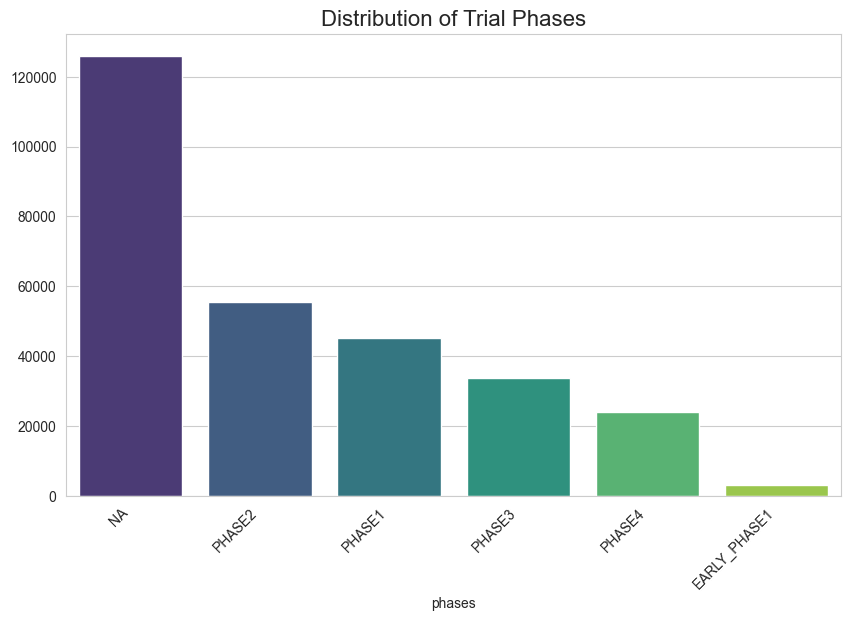

C:\Users\esthe\AppData\Local\Temp\ipykernel_23936\3324141177.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=eda_filtered_df, ax=axes[i], palette='viridis', order=eda_filtered_df[feature].value_counts().index)
C:\Users\esthe\AppData\Local\Temp\ipykernel_23936\3324141177.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=eda_filtered_df, ax=axes[i], palette='viridis', order=eda_filtered_df[feature].value_counts().index)
C:\Users\esthe\AppData\Local\Temp\ipykernel_23936\3324141177.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for

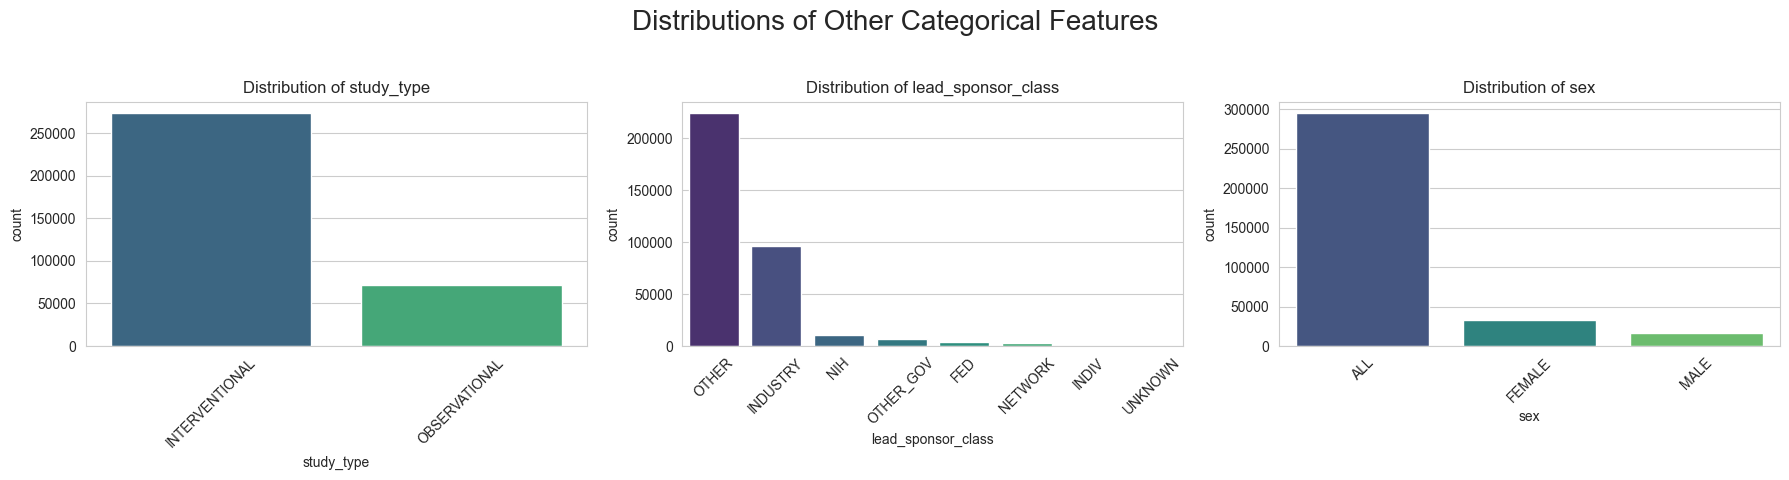

In [9]:
# --- Categorical Feature Distributions ---

# 1. 'phases' column (which contains lists/ndarrays)
print("--- Distribution of Trial Phases ---")
phase_counts = eda_filtered_df['phases'].explode().value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=phase_counts.index, y=phase_counts.values, palette='viridis')
plt.title('Distribution of Trial Phases', fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.show()

# 2. Other categorical features
simple_categorical_features = ['study_type', 'lead_sponsor_class', 'sex']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distributions of Other Categorical Features', fontsize=20)
axes = axes.flatten()
for i, feature in enumerate(simple_categorical_features):
    sns.countplot(x=feature, data=eda_filtered_df, ax=axes[i], palette='viridis', order=eda_filtered_df[feature].value_counts().index)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Interpretation:**
*   **Phases:** The distribution is dominated by "NA" (Not Applicable), which we hypothesize corresponds to observational studies. This is a meaningful category, distinct from truly missing values (NaN values).
*   **Sponsor:** The `lead_sponsor_class` is heavily skewed towards "OTHER", which limits its immediate informativeness but still provides a signal for "INDUSTRY" vs. "NIH" sponsored trials. We discussed the potential of doing a seperate analysis of the indivdual classes within this column, manually grouping them. This is a potential avenu for improving our final model during P3. 
*   **Study Type & Sex:** These features are imbalanced, reflecting the reality of clinical research (more interventional studies, most open to all sexes). This is not a data problem, but rather a real-world pattern our model can learn from.

In [10]:
# --- Numerical Feature Analysis ---
numerical_features = ['enrollment_count', 'minimum_age', 'maximum_age']

# 1. Check data types and summary statistics
print("--- Data Types of Numerical Features ---")
print(eda_filtered_df[numerical_features].dtypes)
print("\n--- Summary Statistics for Numerical Features ---")
display(eda_filtered_df[numerical_features].describe())

--- Data Types of Numerical Features ---
enrollment_count    float64
minimum_age         float64
maximum_age         float64
dtype: object

--- Summary Statistics for Numerical Features ---


,enrollment_count,minimum_age,maximum_age
count,340763.00,322491.00,183888.00
mean,4124.89,20.08,58.63
std,398103.93,11.27,31.16
min,0.00,0.00,1.00
25%,24.00,18.00,45.00
50%,60.00,18.00,65.00
75%,159.00,18.00,75.00
max,188814085.00,730.00,6569.00


**Interpretation of Statistics:**
The summary statistics table is highly revealing:
*   **Skewness:** For all three features, the `mean` is significantly different from the `median` (50%), indicating strong skewness. `enrollment_count` shows the most extreme right skew.
*   **Outliers/Data Quality:** The age columns contain clear data errors or extreme outliers, with a `max` value of 730 for `minimum_age` and 6569 for `maximum_age`. For this baseline proof of concept, we will proceed without removing them. Our chosen baseline model for the structured data (See model justification in the model set up section), a Random Forest, is generally robust to such outliers. However, for a more refined model in P3, a potential improvement would be to either cap these values at a reasonable threshold (e.g., 100 years) or remove these anomalous rows entirely.

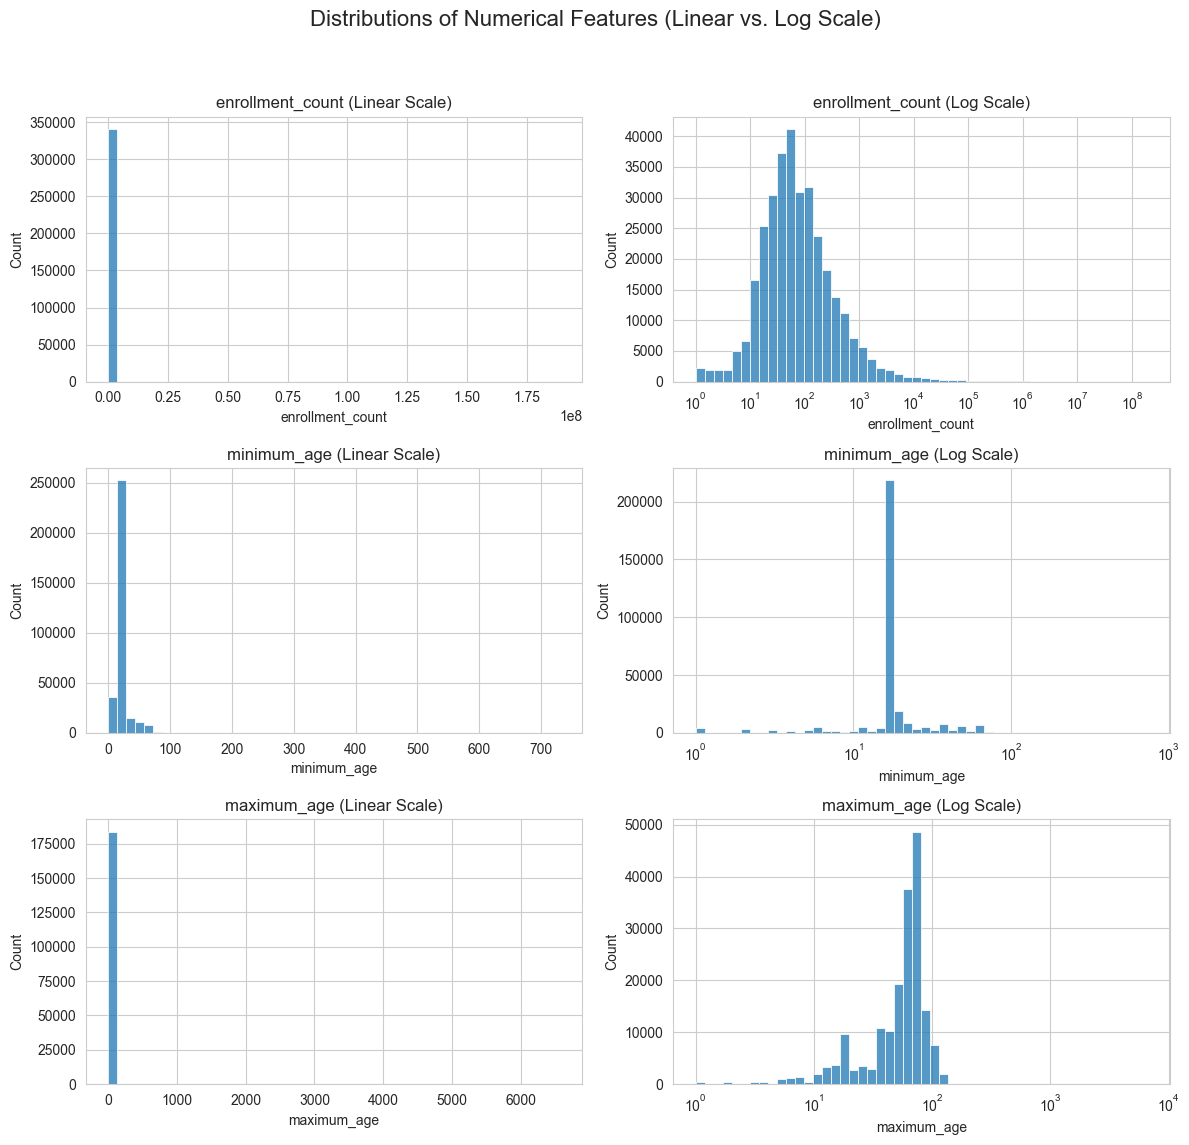

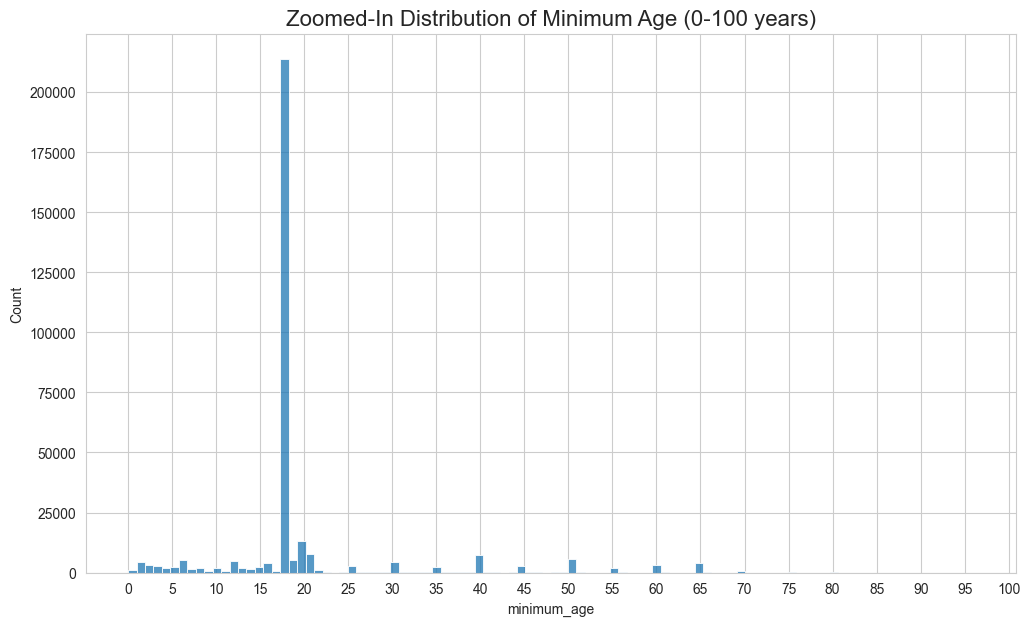

In [12]:
# 2. Plot distributions (Linear vs. Log Scale)
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(12, 12))
fig.suptitle('Distributions of Numerical Features (Linear vs. Log Scale)', fontsize=16)
for i, feature in enumerate(numerical_features):
    sns.histplot(eda_filtered_df[feature], bins=50, kde=False, ax=axes[i, 0]).set_title(f'{feature} (Linear Scale)')
    sns.histplot(eda_filtered_df[feature], bins=50, kde=False, ax=axes[i, 1], log_scale=True).set_title(f'{feature} (Log Scale)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. "Zoomed-in" plot for minimum_age
zoomed_df = eda_filtered_df[eda_filtered_df['minimum_age'] <= 100]
plt.figure(figsize=(12, 7))
sns.histplot(data=zoomed_df, x='minimum_age', bins=100)
plt.title('Zoomed-In Distribution of Minimum Age (0-100 years)', fontsize=16)
plt.xticks(ticks=range(0, 101, 5))
plt.show()

**Interpretation of Plots:**
*   The log-scaled plots confirm the right-skew of `enrollment_count` and `maximum_age`.
*   The zoomed-in plot for `minimum_age` is the most insightful. It proves that this feature does not have a smooth distribution and instead acts like a **categorical variable**, dominated by specific values like 0, 18, and other "round number" age cutoffs (40, 50, 65). This is likely because many studies aimed at lower age groups have specific age requirements where a few years' difference is developmentally significant (e.g., 13 vs. 16 years old), while studies targeting older adults often use broader, round-number cutoffs where the difference between 40 and 42 is less critical. This is an important finding that suggests a simple numerical treatment may be insufficient for a final model. 

### 1.3. Investigating the Text Embeddings

The final step of our EDA was to locate the pre-trained text embeddings mentioned in the dataset's description (`brief_summary_embedding` and `eligibility_criteria_embedding`). These high-dimensional features are central to our project's multimodal hypothesis, as they are expected to capture the rich semantic content of the trial's purpose and its inclusion/exclusion rules.

However, a diagnostic check of the loaded dataset's schema revealed that these embedding columns were not present in the default download configuration.

In [13]:
# --- Diagnostic Check for Embedding Columns ---

# We inspect the columns of our loaded full_df to search for any column containing 'embedding'.
embedding_related_columns = [col for col in full_df.columns if 'embedding' in col.lower()]

if not embedding_related_columns:
    print("Diagnostic Result: No columns containing 'embedding' were found in the initial dataframe.")
    print("\nConclusion: The embeddings must be generated manually.")
else:
    print("Embedding columns found:", embedding_related_columns)

print("\nFull list of available columns:")
print(full_df.columns.tolist())

Diagnostic Result: No columns containing 'embedding' were found in the initial dataframe.

Conclusion: The embeddings must be generated manually.

Full list of available columns:
['nct_id', 'updated_at', 'brief_title', 'official_title', 'acronym', 'study_type', 'overall_status', 'study_first_submit_date', 'start_date', 'primary_completion_date', 'completion_date', 'phases', 'enrollment_count', 'minimum_age', 'maximum_age', 'sex', 'healthy_volunteers', 'brief_summary', 'detailed_description', 'eligibility_criteria', 'lead_sponsor_name', 'lead_sponsor_class', 'org_study_id_info', 'why_stopped', 'expanded_access_info', 'last_update_submit_qc_date', 'last_update_post_date_struct', 'study_first_post_date_struct', 'std_ages', 'study_population', 'sampling_method', 'oversight_has_dmc', 'design_info', 'conditions', 'keywords', 'interventions', 'locations', 'collaborators', 'arm_groups', 'outcomes', 'overall_officials', 'study_references', 'misc_info_module', 'condition_browse_module', 'interve

### Our Solution: Manual Embedding Generation

Given that the embeddings were not pre-packaged, we adapted our plan to generate them ourselves, following the methodology suggested in the dataset's documentation. This represents a significant NLP task that adds depth to our project's proof of concept.

**Workflow:**
1.  **Model Selection:** We used the recommended `thomas-sounack/BioClinical-ModernBERT-base` model from the `sentence-transformers` library, a powerful transformer model pre-trained on biomedical text.
2.  **Computational Constraints:** Generating embeddings for the entire dataset (~540,000 trials) is a computationally intensive process. Our initial attempt to run this on the full dataset in Google Colab timed out after 4.5 hours, having processed only about 30% of the data.
3.  **Subsetting for P2:** To create a feasible and reproducible proof of concept that could be completed within a reasonable timeframe, we created a representative **subset of ~140,000 trials (approx. 25% of the full dataset)**. This size was chosen as a practical balance to ensure the generation process would complete successfully. 
4.  **Generation on Colab:** We performed the embedding generation for both the `brief_summary` and `eligibility_criteria` columns on this subset using a dedicated Google Colab notebook (`subset-embedding-training.ipynb`) with GPU acceleration. This notebook can be found under the appendix in the `README.TXT`. 
5.  **Saving the Result:** The final, enhanced DataFrame—containing all original metadata plus the two new 768-dimensional embedding columns—was saved to a compressed **Parquet file** (`subset_dataset_with_embeddings.parquet`). The dataset is not included in the repo due to size, but you can find the link  under the appendix in the `README.TXT`. 

**Path Forward:**
All subsequent analysis, preprocessing, and modeling in this notebook will be performed on a consistent train/test split derived from this new, enhanced subset dataset. This ensures a fair and direct comparison between our structured data baseline and our embeddings-based models. The code for loading this subset is the first step in our Data Preparation section.

## EDA Conclusion

Our exploratory analysis has provided several good insights that directly inform our project's next steps:
1.  **A Clear (but Imbalanced) Target:** We have successfully defined a binary target variable ("Success" vs. "Failure"), but its severe class imbalance is the primary challenge we must address.
2.  **Informative (but Messy) Features:** The structured features show clear patterns and distributions that we **hypothesize contain predictive signals** (e.g., the difference in `phases` or `study_type`). However, they also suffer from missing data, skewness, and data quality issues (e.g., age outliers). Our preprocessing pipeline must be designed to handle these issues robustly to effectively test this hypothesis.
3.  **A Necessary Workflow Pivot:** The absence of pre-computed embeddings required us to adapt our plan to include a manual generation step, leading to the creation of a smaller, enhanced subset for our proof-of-concept models. We hope to find a way we can train the embeddings for the full dataset during P3. 

With this deep understanding of the data, we are now ready to move on to the formal data preparation and modeling phase.

## 2. Data Preparation and Pipeline

Based on our EDA findings, we now move to the formal data preparation stage. The goal is to create a clean, consistent, and leak-free set of training and testing data for both our structured and embeddings-based models.

### 2.1. The Preprocessing Utility Functions (`utils.py`)

To ensure our preprocessing is modular, reusable, and consistently applied, we have encapsulated the entire logic into two functions stored in a separate `utils.py` file:

1.  **`fit_and_preprocess_train(train_df)`:**
    *   **Purpose:** This function takes the **raw training DataFrame** as input. Its job is to perform all the necessary cleaning and transformation steps while *learning* the parameters required for these transformations (e.g., the median for imputation, the categories for one-hot encoding, the mean/std for scaling).
    *   **Output:** It returns a fully preprocessed training DataFrame and a `transformation_rules` dictionary. This dictionary is a "rulebook" containing all the learned parameters, which is needed for processing the test set.

2.  **`transform_test_data(test_df, rules)`:**
    *   **Purpose:** This function takes the **raw test DataFrame** and the `transformation_rules` dictionary as input.
    *   **Logic:** It applies the *exact same transformations* to the test data, but instead of learning new parameters, it uses the ones saved in the `rules` dictionary. This is the the main step that **prevents data leakage** and ensures the test set is treated as unseen data.
    *   **Output:** It returns a fully preprocessed test DataFrame with the exact same structure as the training set.

This two-function approach guarantees a robust and methodologically sound pipeline for our structured data models.

###  2.2. Load Enhanced Subset and Create Train/Test Split

In [ ]:
# First, we load the subset DataFrame containing the pre-generated embeddings.
# This dataset should be in your working directory! If it isnt, you can find a link to download it in the appendix in the `README.TXT`.
print("Loading the subset dataset with embeddings from Parquet file...")
subset_df_with_embeddings = pd.read_parquet('subset_dataset_with_embeddings.parquet')
print("Dataset loaded.")

# Now, we create the train/test split for the rest of the notebook.
# We want to make sure the same train/test split is used in all baseline models and experiments to ensure we stay consistent and have comparable outcomes. 

# We stratify on 'overall_status' to maintain the class distribution in both sets.
print("\nSplitting the subset into training and testing sets (80/20 split)...")
raw_train_df, raw_test_df = train_test_split(
    subset_df_with_embeddings,
    test_size=0.2,
    random_state=42,
    stratify=subset_df_with_embeddings['overall_status']
)
print("Splitting complete.")
print(f"Raw training set size: {len(raw_train_df)}")
print(f"Raw testing set size: {len(raw_test_df)}")

Loading the subset dataset with embeddings from Parquet file...
Dataset loaded.

Splitting the subset into training and testing sets (80/20 split)...
Splitting complete.
Raw training set size: 112000
Raw testing set size: 28000


### 2.3. Execute the Structured Data Preprocessing Pipeline

In [ ]:
# We now feed our raw splits into the utility functions.
print("\nPreprocessing structured data for the baseline model...")

# The fit_and_preprocess_train function learns rules ONLY from the training set.
processed_train_df, new_transformation_rules = fit_and_preprocess_train(raw_train_df)

# The transform_test_data function applies those learned rules to the test set.
processed_test_df = transform_test_data(raw_test_df, new_transformation_rules)

print("\nStructured data preprocessing complete.")

# Display the head of the final processed training data to confirm the structure.
print("\nHead of the final processed training data (for structured model):")
display(processed_train_df.head())


Preprocessing structured data for the baseline model...
Dropped 950 rows with missing 'sex' or 'enrollment_count'.
Training data preprocessed successfully according to the specific plan.
Test data transformed successfully using training set rules.

Structured data preprocessing complete.

Head of the final processed training data (for structured model):


,enrollment_count,minimum_age,maximum_age,phases_EARLY_PHASE1,phases_NA,phases_PHASE1,phases_PHASE2,phases_PHASE3,phases_PHASE4,phases_Unknown,...,lead_sponsor_class_INDUSTRY,lead_sponsor_class_NETWORK,lead_sponsor_class_NIH,lead_sponsor_class_OTHER,lead_sponsor_class_OTHER_GOV,lead_sponsor_class_UNKNOWN,sex_ALL,sex_FEMALE,sex_MALE,target
76856,-0.01,-0.18,-2.01,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1
3206,-0.01,-0.18,0.15,0.00,0.00,0.00,0.00,0.00,0.00,1.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1
73216,-0.01,2.77,0.15,0.00,0.00,0.00,0.00,1.00,0.00,0.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0
1259,-0.02,-0.08,0.15,0.00,0.00,0.00,1.00,0.00,0.00,0.00,...,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0
120625,-0.01,-0.73,0.47,0.00,0.00,0.00,1.00,0.00,0.00,0.00,...,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1


#### **Section 1: Setup and Data Loading**
*   **Cell 1 (Markdown):** `# Project: Predicting Clinical Trial Success` (A main title). Briefly state the project goal in one or two sentences.
*   **Cell 2 (Code):** All your library imports (`pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn` models, `datasets`, etc.).
*   **Cell 3 (Code):** Load the raw dataset using `load_dataset`. Convert it to a single pandas DataFrame (`full_df`). Display the `.head()` and `.info()` to show the initial state of the data.

#### **Section 2: Exploratory Data Analysis (EDA)**
*   **Cell 4 (Markdown):** `## 1. Exploratory Data Analysis`. Write a brief introduction explaining that this section is for understanding the data's properties.
*   **Cell 5 (Code & Markdown):** **Target Variable Analysis.** Show the `value_counts()` and bar plot of the original `overall_status`. Follow this with a markdown cell explaining your logic for creating the binary "Success/Failure" target.
*   **Cell 6 (Code):** The code that actually creates the binary target on a *temporary* filtered DataFrame and shows the new balanced/imbalanced plot. (This is for EDA visualization only).
*   **Cell 7 (Markdown):** A subtitle for analyzing structured features.
*   **Cell 8 (Code & Markdown):** **Missing Values Analysis.** Show the percentage of missing values for your chosen features. Add a markdown cell interpreting the results and stating your initial plan for handling them (drop vs. impute).
*   **Cell 9 (Code & Markdown):** **Categorical Feature Analysis.** Show the plots for `phases`, `study_type`, etc. Follow with a markdown cell summarizing your findings (the "NA" category in phases, the "OTHER" dominance in sponsors).
*   **Cell 10 (Code & Markdown):** **Numerical Feature Analysis.**
    *   First, show the `.describe()` table.
    *   Add a markdown cell analyzing the table, pointing out the skew by comparing the mean and median, and noting the outliers in the age columns.
    *   Then, show the side-by-side linear vs. log scale plots.
    *   Finally, show the "zoomed-in" plot for `minimum_age` and add a markdown cell explaining your conclusion that it acts like a categorical feature.
*   **Cell 11 (Markdown):** **EDA Conclusion.** A short summary of the key takeaways from the EDA (imbalance, skew, data quality issues) that will inform the preprocessing pipeline.

#### **Section 3: Data Splitting and Preprocessing**
*   **Cell 12 (Markdown):** `## 2. Data Splitting and Preprocessing`. Explain that you are now creating the definitive train/test split *before* any model-specific processing to prevent data leakage.
*   **Cell 13 (Code):** The `train_test_split` code that creates `raw_train_df` and `raw_test_df` from `full_df_with_embeddings`. Print the shapes of the resulting DataFrames.
*   **Cell 14 (Code):** Import your `utils.py` functions. Run `fit_and_preprocess_train` and `transform_test_data`. Display the `.head()` of `processed_train_df` and `processed_test_df` to show they are ready.

#### **Section 4: Baseline Model 1 (Structured Data)**
*   **Cell 15 (Markdown):** `## 3. Baseline Model: Structured Metadata`. Introduce the goal of this section and your choice of a `RandomForestClassifier`.
*   **Cell 16 (Code):** Prepare the `X_train`, `y_train`, `X_test`, `y_test` variables from your `processed_` DataFrames.
*   **Cell 17 (Code):** Initialize, train (`.fit()`), and predict (`.predict()`) with the `RandomForestClassifier`.
*   **Cell 18 (Code & Markdown):** **Evaluation.** Show the `classification_report` and the `ConfusionMatrixDisplay`. Follow this with the detailed markdown analysis of the performance that we crafted.

#### **Section 5: Baseline Model 2 (Text Embeddings)**
*   **Cell 19 (Markdown):** `## 4. Embeddings Model: Initial Version`. Introduce this section as per your advisor's request.
*   **Cell 20 (Markdown):** `### 4a. Linear Model (Logistic Regression)`. Sub-header.
*   **Cell 21 (Code):** Prepare the embeddings data (`X_train_emb_np`, `y_train_emb`, etc.) from your `raw_` DataFrames.
*   **Cell 22 (Code):** Train and evaluate the `LogisticRegression` model, showing the report and confusion matrix.
*   **Cell 23 (Markdown):** A markdown cell analyzing the (poor) performance of the logistic regression model.
*   **Cell 24 (Markdown):** `### 4b. Non-Linear Model (Random Forest)`. Sub-header.
*   **Cell 25 (Code):** Train and evaluate the `RandomForestClassifier` on the embeddings data, showing the report and matrix.
*   **Cell 26 (Markdown):** A markdown cell analyzing the "lazy classifier" result of this model.
*   **Cell 27 (Markdown):** `### 4c. Downsampling Experiment`. Sub-header.
*   **Cell 28 (Code):** The code for the downsampling experiment, training, and evaluation.
*   **Cell 29 (Markdown):** The final analysis of the downsampling experiment, explaining why it was a success.

#### **Section 6: Conclusion and Next Steps**
*   **Cell 30 (Markdown):** `## 5. P2 Conclusion and Next Steps for P3`.
    *   **Summary:** Briefly summarize the performance of all models. State that the structured data baseline performed decently but suffered from imbalance, and the simple embedding models performed poorly without balancing.
    *   **Conclusion:** Conclude that the P2 proof of concept was successful and has identified class imbalance as the key challenge.
    *   **Next Steps for P3:** State your clear plan: 1) Apply downsampling to improve both baselines. 2) Build the final multimodal model by combining the balanced structured data and the embeddings. 3) Compare all results to draw a final conclusion.

This structure is clean, tells a compelling story of investigation and discovery, and directly maps to every requirement of the P2 milestone.